# HEROS Phase 2 — Exploratory Data Analysis

**Project:** Chinatown HEROS (Health & Environmental Research in Open Spaces)  
**Study period:** July 19 – August 23, 2023  
**Dataset:** 48,123 rows × 48 columns (cleaned in Phase 1)

This notebook demonstrates the complete Phase 2 EDA pipeline — univariate distributions, temporal patterns, spatial comparisons, correlations, land-use analysis, and site geolocation.

## Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
%matplotlib inline

# Paths (relative to reports/phase2/)
DATA = Path('../../data/clean/data_HEROS_clean.parquet')
FIGURES = Path('../../figures')
FIGURES.mkdir(exist_ok=True)

# Style
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("tab10", 12)
PM_COLOR = "#4C72B0"
TEMP_COLOR = "#DD8452"
WBGT_COLOR = "#C44E52"
HUMID_COLOR = "#55A868"
WIND_COLOR = "#8172B3"

SITE_NAMES = {
    "berkley": "Berkeley Garden", "castle": "Castle Square",
    "chin": "Chin Park", "dewey": "Dewey Square",
    "eliotnorton": "Eliot Norton Park", "greenway": "One Greenway",
    "lyndenboro": "Lyndboro Park", "msh": "Mary Soo Hoo Park",
    "oxford": "Oxford Place Plaza", "reggie": "Reggie Wong Park",
    "taitung": "Tai Tung Park", "tufts": "Tufts Community Garden",
}

report = {}

## Load cleaned data

In [ ]:
df = pd.read_parquet(DATA)
df["datetime"] = pd.to_datetime(df["datetime"])
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Key variable groups
SENSOR_VARS = {
    "pa_mean_pm2_5_atm_b_corr_2": ("PM2.5 (Purple Air)", "µg/m³", PM_COLOR),
    "kes_mean_temp_f": ("Temperature (Kestrel)", "°F", TEMP_COLOR),
    "kes_mean_wbgt_f": ("WBGT (Kestrel)", "°F", WBGT_COLOR),
    "kes_mean_humid_pct": ("Humidity (Kestrel)", "%", HUMID_COLOR),
    "mean_wind_speed_mph": ("Wind Speed", "mph", WIND_COLOR),
    "wind_direction_degrees_kr": ("Wind Direction", "degrees", "#937860"),
}

EPA_VARS = {
    "epa_ozone": ("EPA Ozone", "ppm"),
    "epa_so2": ("EPA SO₂", "ppb"),
    "epa_co": ("EPA CO", "ppm"),
    "epa_no2": ("EPA NO₂", "ppb"),
    "epa_pm25_fem": ("EPA PM2.5 FEM", "µg/m³"),
}

Loaded: 48,123 rows × 46 columns


## 2.1 — Univariate Analysis

Histograms with mean/median lines for all key sensor variables, plus a summary statistics table.

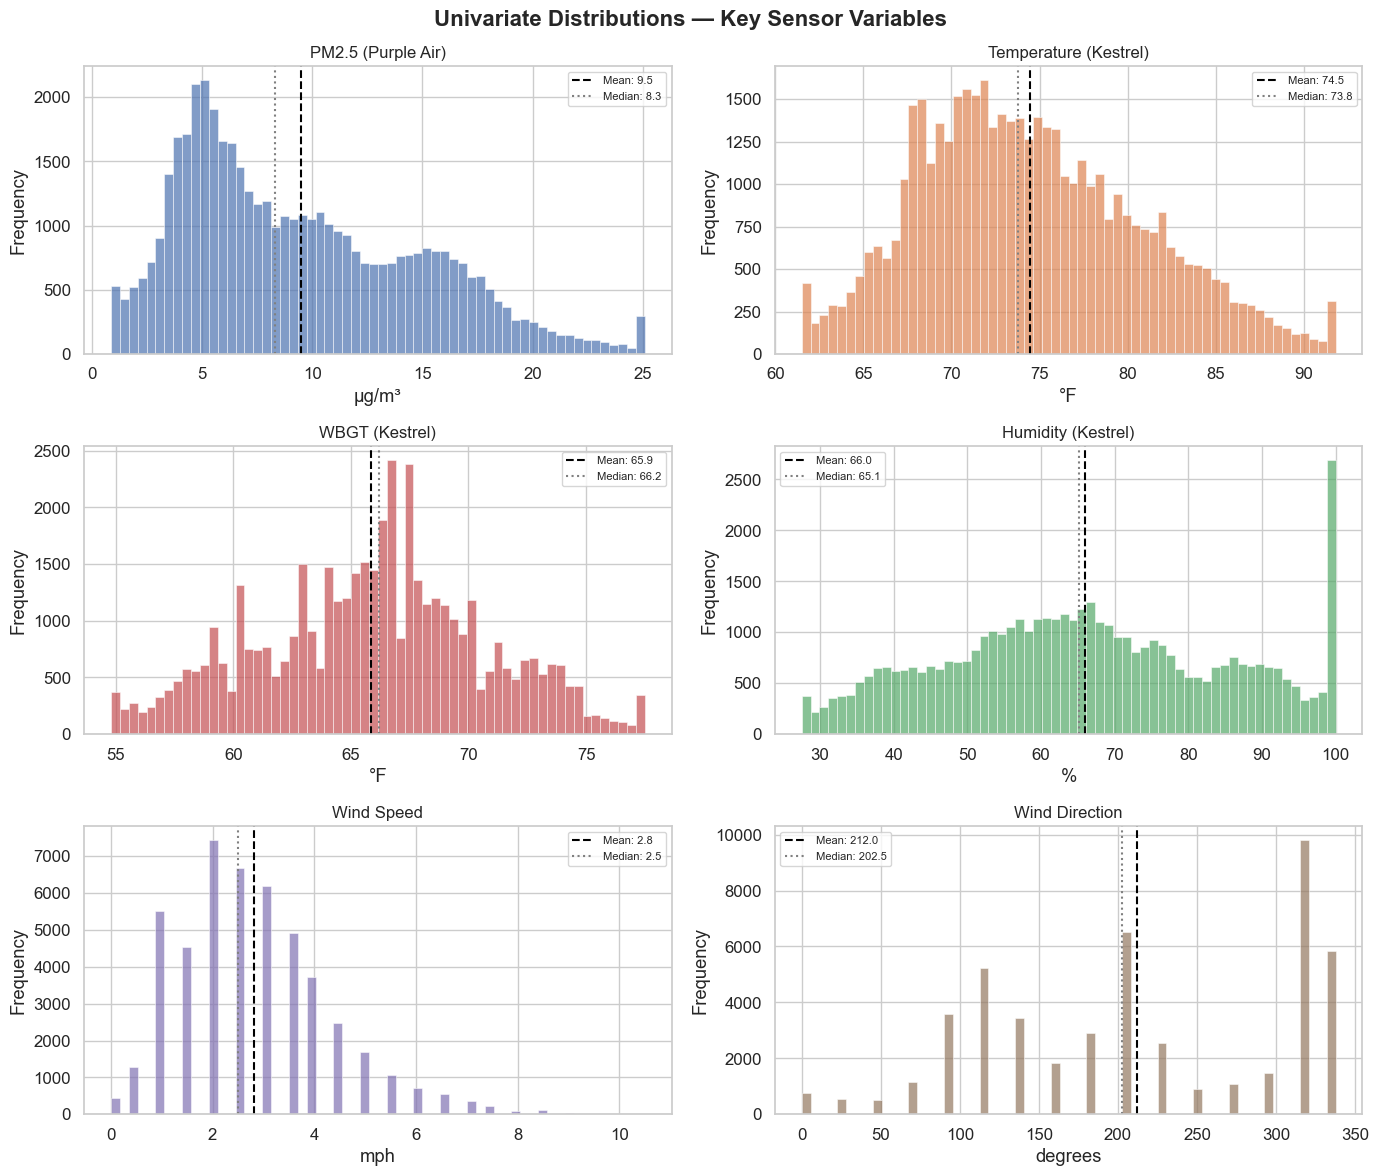

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Univariate Distributions — Key Sensor Variables", fontsize=16, fontweight="bold")

for ax, (col, (label, unit, color)) in zip(axes.flat, SENSOR_VARS.items()):
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor="white", linewidth=0.5)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(f"{unit}")
    ax.set_ylabel("Frequency")
    ax.axvline(data.mean(), color="black", ls="--", lw=1.5, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="gray", ls=":", lw=1.5, label=f"Median: {data.median():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics table
uni_stats = {}
for col, (label, unit, _) in SENSOR_VARS.items():
    s = df[col].describe()
    uni_stats[label] = {
        "unit": unit, "count": int(s["count"]), "mean": round(s["mean"], 2),
        "std": round(s["std"], 2), "min": round(s["min"], 2),
        "q25": round(s["25%"], 2), "median": round(s["50%"], 2),
        "q75": round(s["75%"], 2), "max": round(s["max"], 2),
        "skew": round(df[col].skew(), 3),
    }
report["univariate"] = uni_stats
display(pd.DataFrame(uni_stats).T)

,unit,count,mean,std,min,q25,median,q75,max,skew
PM2.5 (Purple Air),µg/m³,47009,9.49,5.34,0.88,5.12,8.33,13.43,25.09,0.648
Temperature (Kestrel),°F,46404,74.47,6.33,61.5,69.7,73.8,78.7,91.8,0.4
WBGT (Kestrel),°F,46404,65.86,4.82,54.8,62.6,66.2,68.9,77.5,-0.047
Humidity (Kestrel),%,46404,65.95,18.89,27.5,52.2,65.1,80.1,100.0,0.073
Wind Speed,mph,48123,2.81,1.5,0.0,2.0,2.5,3.5,10.5,0.878
Wind Direction,degrees,48123,211.95,95.37,0.0,135.0,202.5,315.0,337.5,-0.17


## 2.2 — Temporal Patterns

### Time series (all sites)
- **PM2.5 peaks** during late July / early August episodes (likely wildfire transport)
- **Temperature** follows expected summer diurnal cycle
- **WBGT** peaks later in the day than temperature due to humidity modulation

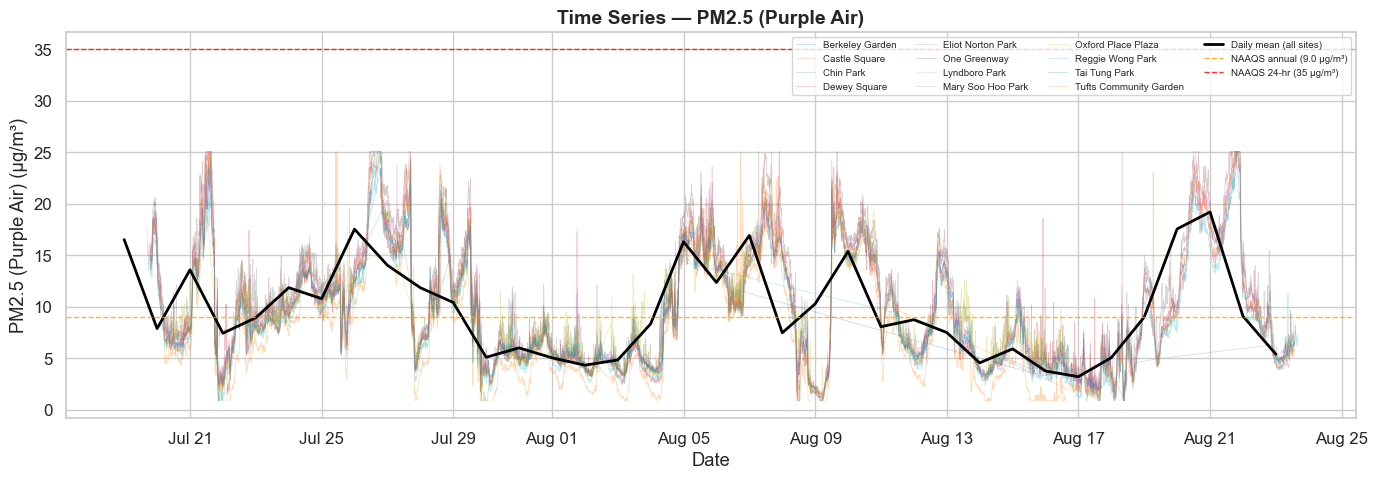

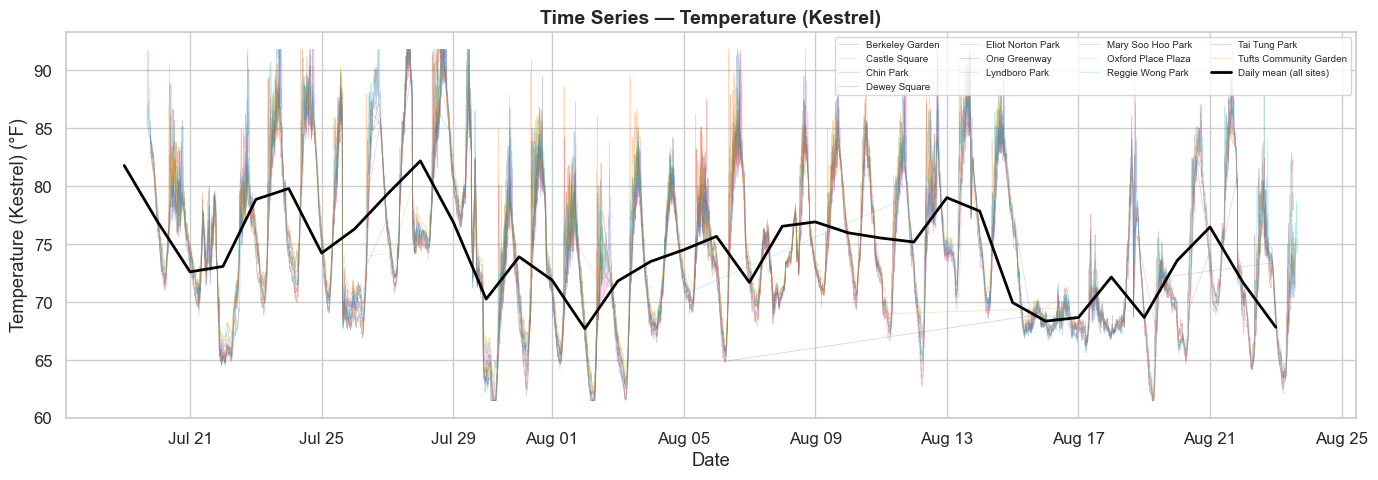

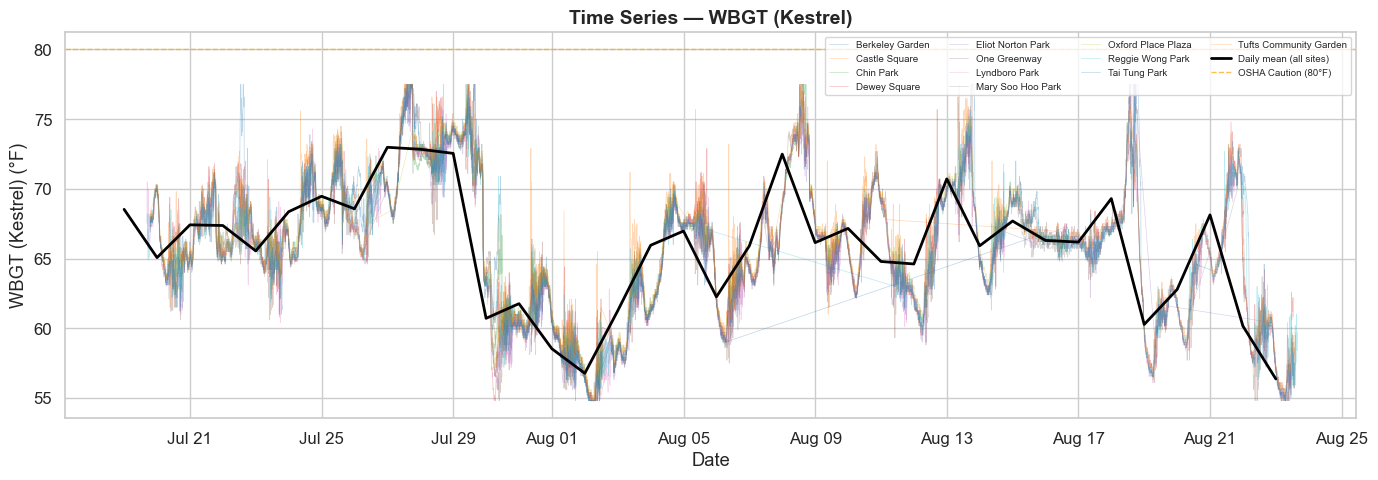

In [ ]:
# Time series for PM2.5, Temperature, WBGT
for col, label, unit, color in [
    ("pa_mean_pm2_5_atm_b_corr_2", "PM2.5 (Purple Air)", "µg/m³", PM_COLOR),
    ("kes_mean_temp_f", "Temperature (Kestrel)", "°F", TEMP_COLOR),
    ("kes_mean_wbgt_f", "WBGT (Kestrel)", "°F", WBGT_COLOR),
]:
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, (site, grp) in enumerate(df.groupby("site_id")):
        ax.plot(grp["datetime"], grp[col], alpha=0.3, lw=0.5, color=PALETTE[i],
                label=SITE_NAMES.get(site, site))
    # Daily mean overlay
    daily = df.groupby(df["datetime"].dt.date)[col].mean()
    ax.plot(pd.to_datetime(daily.index), daily.values, color="black", lw=2, label="Daily mean (all sites)")
    if "pm2_5" in col:
        ax.axhline(9.0, color="orange", ls="--", lw=1, alpha=0.8, label="NAAQS annual (9.0 µg/m³)")
        ax.axhline(35.0, color="red", ls="--", lw=1, alpha=0.8, label="NAAQS 24-hr (35 µg/m³)")
    if "wbgt" in col:
        ax.axhline(80, color="orange", ls="--", lw=1, alpha=0.7, label="OSHA Caution (80°F)")
    ax.set_title(f"Time Series — {label}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{label} ({unit})")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend(fontsize=7, ncol=4, loc="upper right")
    plt.tight_layout()
    plt.show()

### Diurnal cycles (hour-of-day)

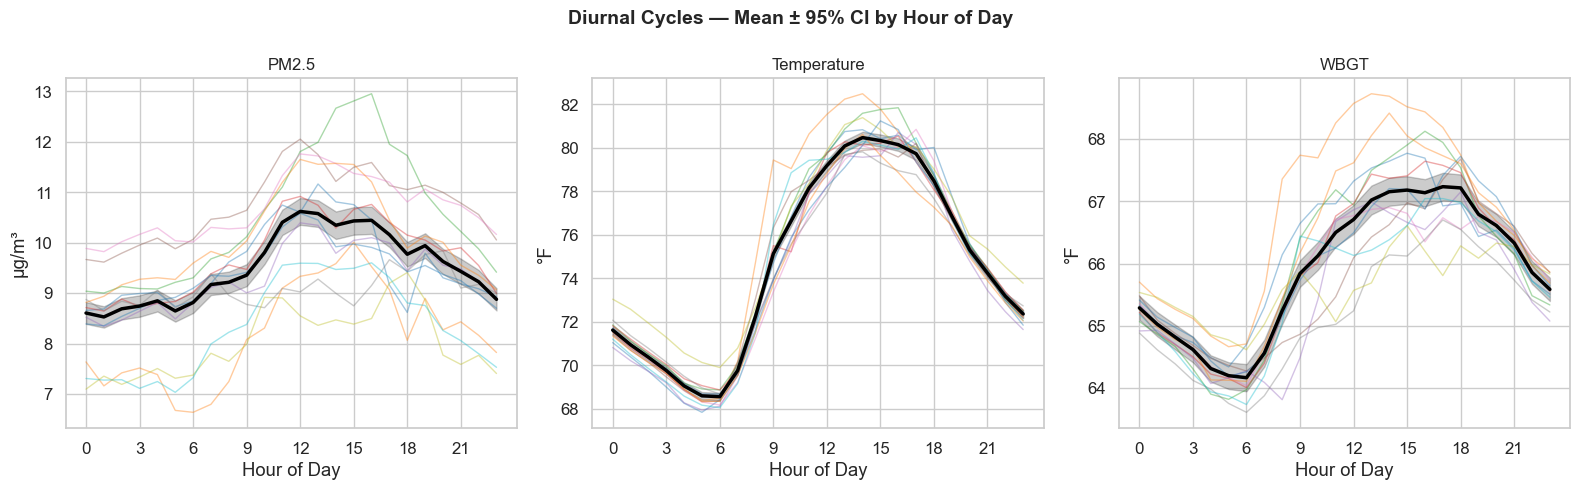

PM2.5 peak hour: 12
Temperature peak hour: 14
WBGT peak hour: 17


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Diurnal Cycles — Mean ± 95% CI by Hour of Day", fontsize=14, fontweight="bold")

for ax, (col, label, unit, color) in zip(axes, [
    ("pa_mean_pm2_5_atm_b_corr_2", "PM2.5", "µg/m³", PM_COLOR),
    ("kes_mean_temp_f", "Temperature", "°F", TEMP_COLOR),
    ("kes_mean_wbgt_f", "WBGT", "°F", WBGT_COLOR),
]):
    for i, (site, grp) in enumerate(df.groupby("site_id")):
        hourly = grp.groupby("hour")[col].mean()
        ax.plot(hourly.index, hourly.values, alpha=0.4, lw=1, color=PALETTE[i])
    overall = df.groupby("hour")[col].agg(["mean", "sem"])
    ax.plot(overall.index, overall["mean"], color="black", lw=2.5, label="All sites mean")
    ax.fill_between(overall.index, overall["mean"] - 1.96 * overall["sem"],
                     overall["mean"] + 1.96 * overall["sem"], alpha=0.2, color="black")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel(f"{unit}")
    ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

# Peak hours
print(f"PM2.5 peak hour: {df.groupby('hour')['pa_mean_pm2_5_atm_b_corr_2'].mean().idxmax()}")
print(f"Temperature peak hour: {df.groupby('hour')['kes_mean_temp_f'].mean().idxmax()}")
print(f"WBGT peak hour: {df.groupby('hour')['kes_mean_wbgt_f'].mean().idxmax()}")

### Day-of-week patterns

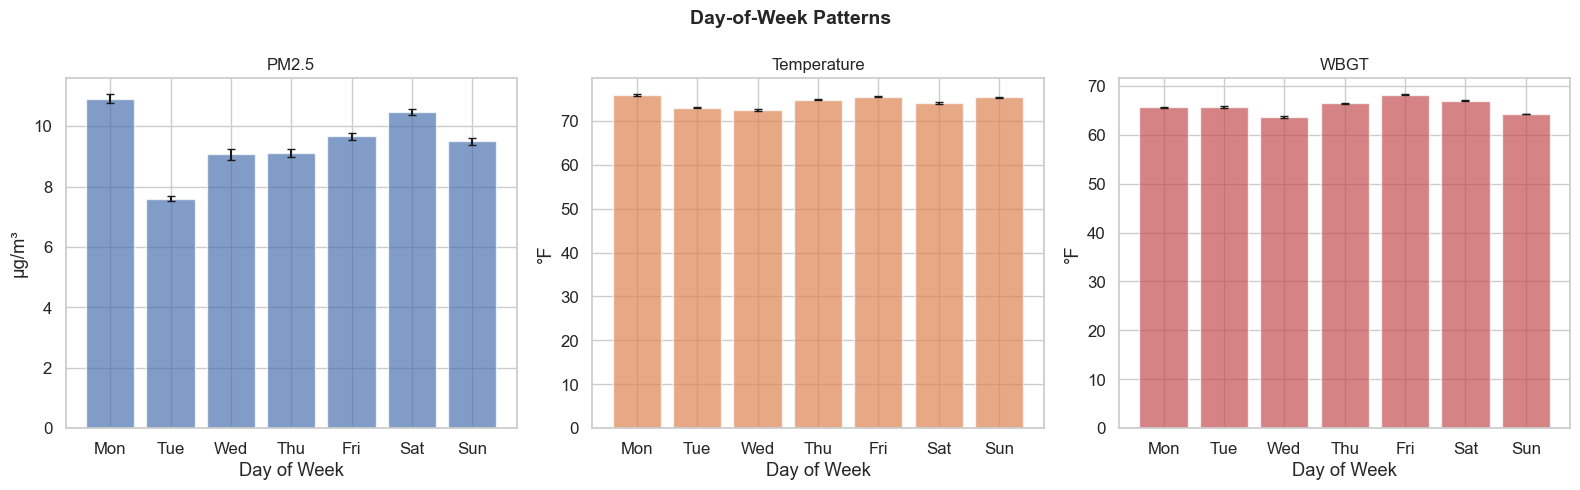

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Day-of-Week Patterns", fontsize=14, fontweight="bold")
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for ax, (col, label, unit, color) in zip(axes, [
    ("pa_mean_pm2_5_atm_b_corr_2", "PM2.5", "µg/m³", PM_COLOR),
    ("kes_mean_temp_f", "Temperature", "°F", TEMP_COLOR),
    ("kes_mean_wbgt_f", "WBGT", "°F", WBGT_COLOR),
]):
    dow = df.groupby("day_of_week")[col].agg(["mean", "sem"])
    ax.bar(dow.index, dow["mean"], yerr=1.96 * dow["sem"], color=color, alpha=0.7,
           capsize=3, edgecolor="white")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Day of Week")
    ax.set_ylabel(f"{unit}")
    ax.set_xticks(range(7))
    ax.set_xticklabels(DOW_LABELS)

plt.tight_layout()
plt.show()

report["temporal"] = {
    "diurnal_pm25_peak_hour": int(df.groupby("hour")["pa_mean_pm2_5_atm_b_corr_2"].mean().idxmax()),
    "diurnal_temp_peak_hour": int(df.groupby("hour")["kes_mean_temp_f"].mean().idxmax()),
    "diurnal_wbgt_peak_hour": int(df.groupby("hour")["kes_mean_wbgt_f"].mean().idxmax()),
}

### Hour × Day-of-Week heatmaps

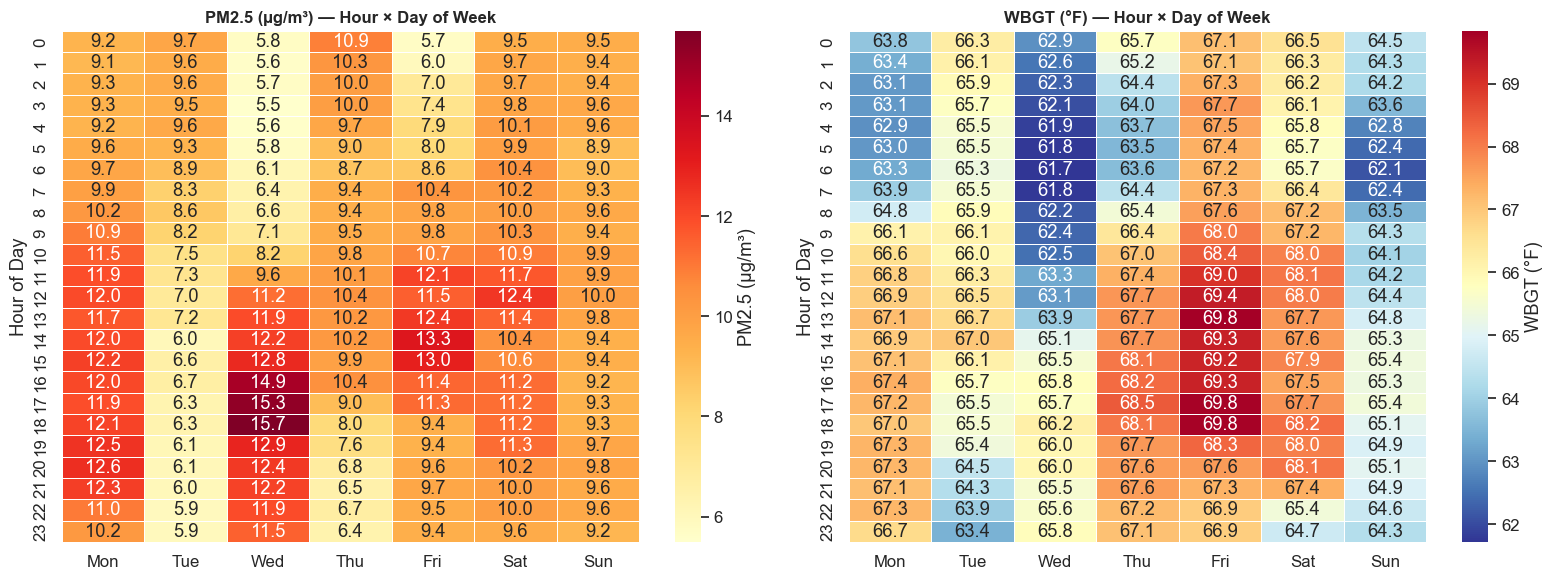

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for ax, (col, label, cmap) in zip(axes, [
    ("pa_mean_pm2_5_atm_b_corr_2", "PM2.5 (µg/m³)", "YlOrRd"),
    ("kes_mean_wbgt_f", "WBGT (°F)", "RdYlBu_r"),
]):
    pivot = df.pivot_table(values=col, index="hour", columns="day_of_week", aggfunc="mean")
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt=".1f", linewidths=0.5,
                xticklabels=DOW_LABELS, cbar_kws={"label": label})
    ax.set_title(f"{label} — Hour × Day of Week", fontsize=12, fontweight="bold")
    ax.set_ylabel("Hour of Day")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

## 2.3 — Spatial Overview

Site-level distributions reveal a ~3 µg/m³ PM2.5 spread across the 12 sites.

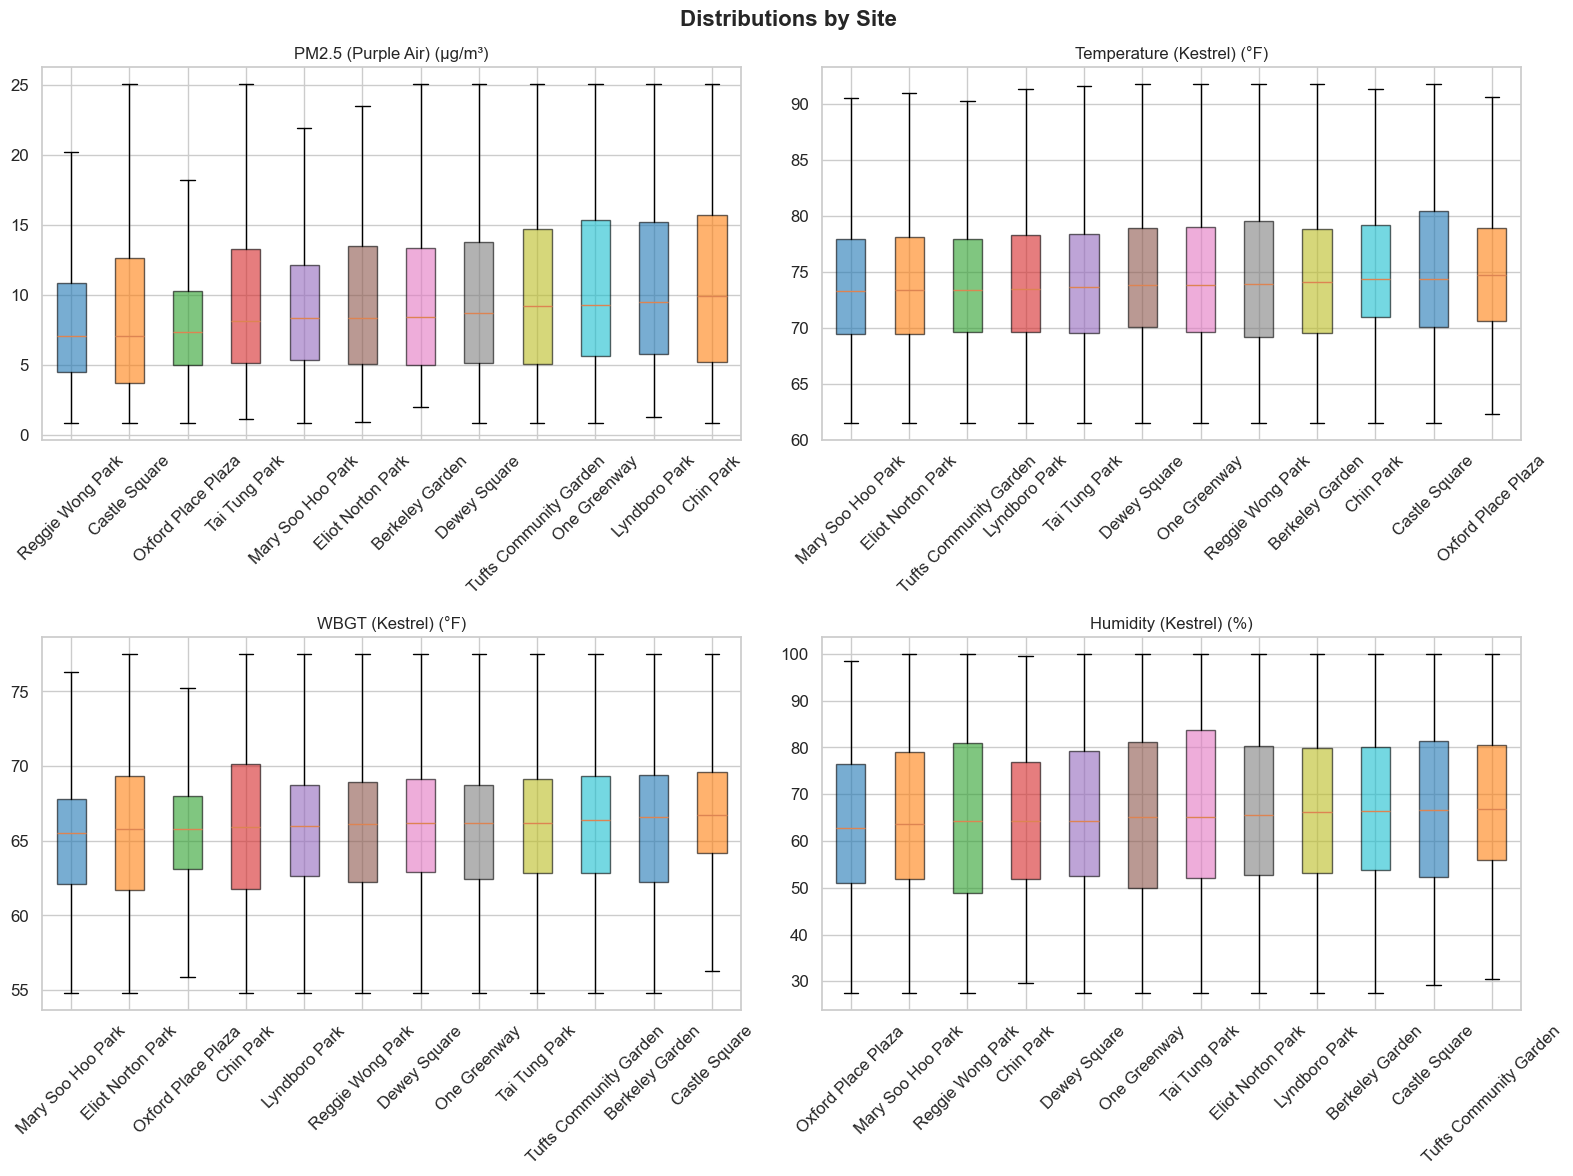

In [ ]:
# Boxplots by site
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Distributions by Site", fontsize=16, fontweight="bold")

for ax, (col, label, unit) in zip(axes.flat, [
    ("pa_mean_pm2_5_atm_b_corr_2", "PM2.5 (Purple Air)", "µg/m³"),
    ("kes_mean_temp_f", "Temperature (Kestrel)", "°F"),
    ("kes_mean_wbgt_f", "WBGT (Kestrel)", "°F"),
    ("kes_mean_humid_pct", "Humidity (Kestrel)", "%"),
]):
    site_order = df.groupby("site_id")[col].median().sort_values().index.tolist()
    site_labels = [SITE_NAMES.get(s, s) for s in site_order]
    box_data = [df[df["site_id"] == s][col].dropna().values for s in site_order]
    bp = ax.boxplot(box_data, labels=site_labels, patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f"{label} ({unit})", fontsize=12)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

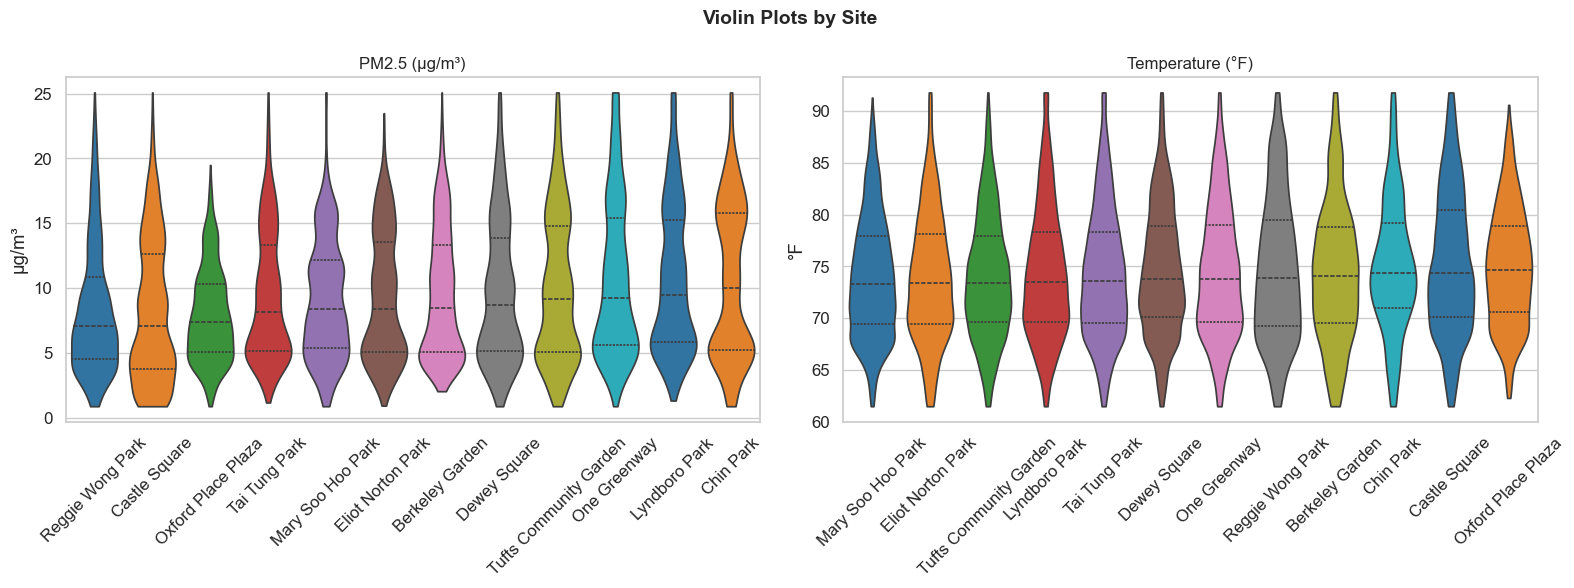

In [ ]:
# Violin plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Violin Plots by Site", fontsize=14, fontweight="bold")

for ax, (col, label, unit) in zip(axes, [
    ("pa_mean_pm2_5_atm_b_corr_2", "PM2.5 (µg/m³)", "µg/m³"),
    ("kes_mean_temp_f", "Temperature (°F)", "°F"),
]):
    site_order = df.groupby("site_id")[col].median().sort_values().index.tolist()
    plot_df = df[["site_id", col]].dropna()
    plot_df["site_label"] = plot_df["site_id"].map(SITE_NAMES)
    label_order = [SITE_NAMES[s] for s in site_order]
    sns.violinplot(data=plot_df, x="site_label", y=col, order=label_order,
                   ax=ax, palette=PALETTE, inner="quartile", cut=0)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel(unit)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Site-level summary table
site_summary = {}
for site in sorted(df["site_id"].unique()):
    s = df[df["site_id"] == site]
    site_summary[site] = {
        "name": SITE_NAMES[site],
        "n_obs": len(s),
        "pm25_mean": round(s["pa_mean_pm2_5_atm_b_corr_2"].mean(), 2),
        "pm25_median": round(s["pa_mean_pm2_5_atm_b_corr_2"].median(), 2),
        "temp_mean": round(s["kes_mean_temp_f"].mean(), 2),
        "wbgt_mean": round(s["kes_mean_wbgt_f"].mean(), 2),
        "humid_mean": round(s["kes_mean_humid_pct"].mean(), 2),
    }
report["spatial"] = site_summary

site_df = pd.DataFrame(site_summary).T.sort_values("pm25_mean", ascending=False)
display(site_df[["name", "n_obs", "pm25_mean", "temp_mean", "wbgt_mean", "humid_mean"]])

,name,n_obs,pm25_mean,temp_mean,wbgt_mean,humid_mean
greenway,One Greenway,4893,10.71,74.5,65.73,65.65
lyndenboro,Lyndboro Park,4786,10.68,74.37,65.83,66.29
chin,Chin Park,2199,10.49,75.02,66.01,64.28
tufts,Tufts Community Garden,4095,10.04,73.98,66.21,68.53
dewey,Dewey Square,4903,9.69,74.57,65.92,65.74
berkley,Berkeley Garden,2445,9.53,74.41,66.1,67.18
taitung,Tai Tung Park,4839,9.37,74.34,65.94,66.96
eliotnorton,Eliot Norton Park,3888,9.29,73.93,65.48,66.09
msh,Mary Soo Hoo Park,4189,9.07,73.91,65.09,64.67
reggie,Reggie Wong Park,4126,8.34,74.67,65.67,65.0


## 2.4 — Correlation Matrix

14×14 pairwise correlation heatmap across all environmental monitoring variables.

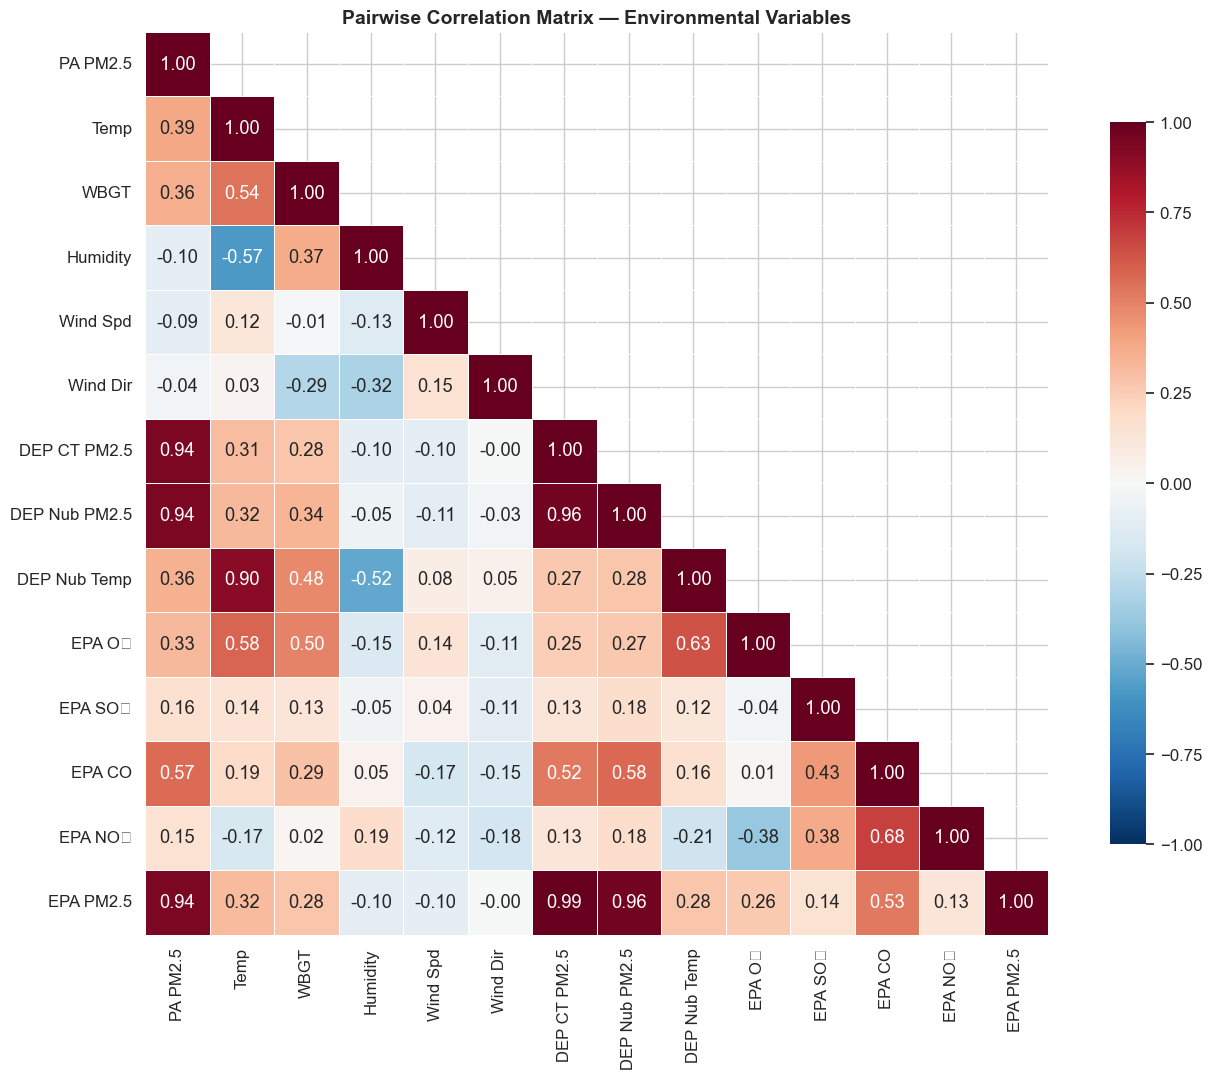

Key correlations:
  PA_PM25 vs DEP_CT: r = 0.939
  PA_PM25 vs DEP_Nub: r = 0.942
  PA_PM25 vs EPA_PM25: r = 0.94
  Temp vs WBGT: r = 0.541
  PM25 vs Temp: r = 0.386
  Ozone vs Temp: r = 0.584


In [ ]:
corr_cols = [
    "pa_mean_pm2_5_atm_b_corr_2", "kes_mean_temp_f", "kes_mean_wbgt_f",
    "kes_mean_humid_pct", "mean_wind_speed_mph", "wind_direction_degrees_kr",
    "dep_FEM_chinatown_pm2_5_ug_m3", "dep_FEM_nubian_pm2_5_ug_m3",
    "dep_FEM_nubian_temp_f", "epa_ozone", "epa_so2", "epa_co", "epa_no2", "epa_pm25_fem",
]
corr_labels = [
    "PA PM2.5", "Temp", "WBGT", "Humidity", "Wind Spd", "Wind Dir",
    "DEP CT PM2.5", "DEP Nub PM2.5", "DEP Nub Temp",
    "EPA O₃", "EPA SO₂", "EPA CO", "EPA NO₂", "EPA PM2.5",
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            xticklabels=corr_labels, yticklabels=corr_labels, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pairwise Correlation Matrix — Environmental Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Key correlations
key_corrs = {
    "PA_PM25 vs DEP_CT": round(corr_matrix.loc["pa_mean_pm2_5_atm_b_corr_2", "dep_FEM_chinatown_pm2_5_ug_m3"], 3),
    "PA_PM25 vs DEP_Nub": round(corr_matrix.loc["pa_mean_pm2_5_atm_b_corr_2", "dep_FEM_nubian_pm2_5_ug_m3"], 3),
    "PA_PM25 vs EPA_PM25": round(corr_matrix.loc["pa_mean_pm2_5_atm_b_corr_2", "epa_pm25_fem"], 3),
    "Temp vs WBGT": round(corr_matrix.loc["kes_mean_temp_f", "kes_mean_wbgt_f"], 3),
    "PM25 vs Temp": round(corr_matrix.loc["pa_mean_pm2_5_atm_b_corr_2", "kes_mean_temp_f"], 3),
    "Ozone vs Temp": round(corr_matrix.loc["epa_ozone", "kes_mean_temp_f"], 3),
}
report["correlations"] = key_corrs
print("Key correlations:")
for k, v in key_corrs.items():
    print(f"  {k}: r = {v}")

## 2.5 — Land-Use Summary

Land-use composition from MassGIS at 25m and 50m buffer distances around each site. Impervious surface dominates most sites.

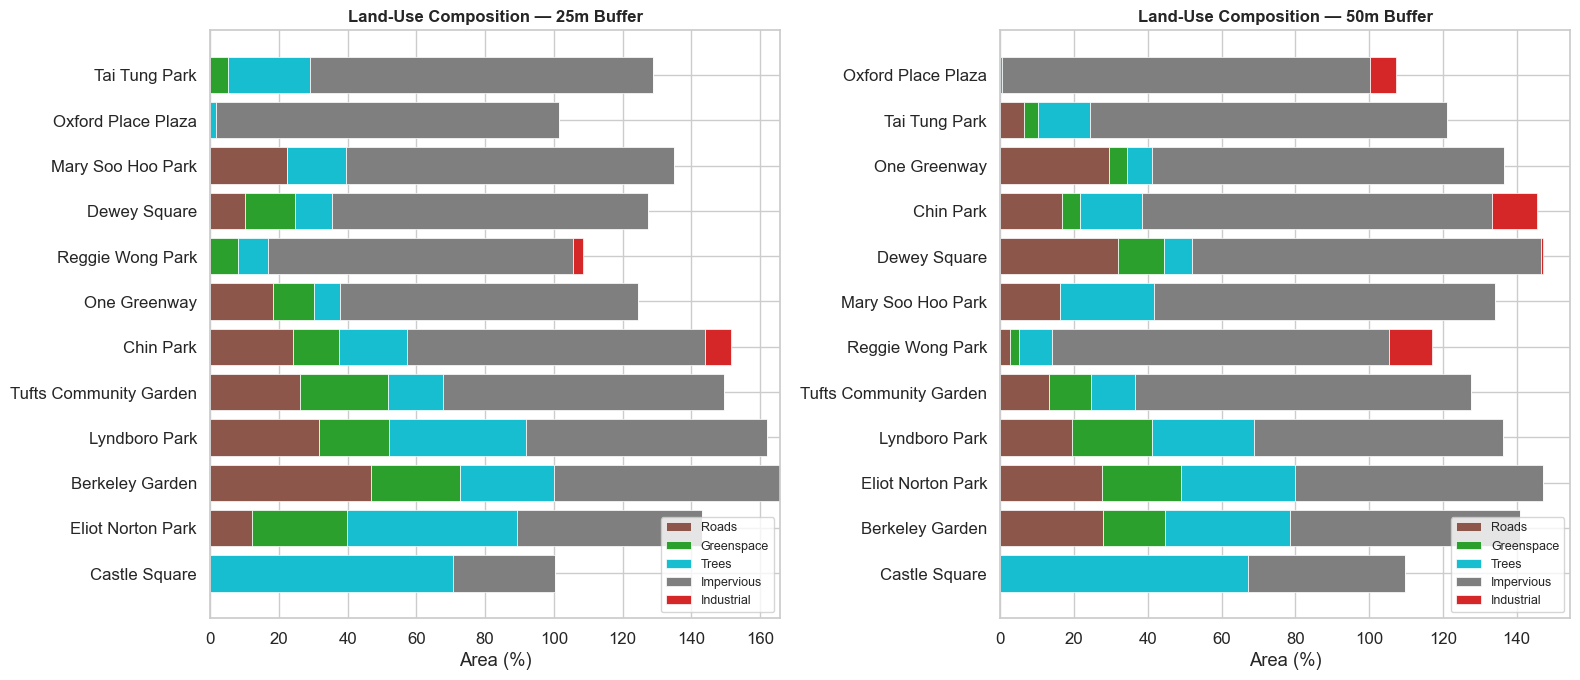

In [ ]:
lu_cols_25 = ["Roads_Area_Percent_25m", "Greenspace_Area_Percent_25m", "Trees_Area_Percent_25m",
              "Impervious_Area_Percent_25m", "Industrial_Area_Percent_25m"]
lu_cols_50 = [c.replace("25m", "50m") for c in lu_cols_25]
lu_labels = ["Roads", "Greenspace", "Trees", "Impervious", "Industrial"]

# Per-site land-use (constant for every row of a site)
lu_site = df.groupby("site_id")[lu_cols_25 + lu_cols_50].first()

# Stacked bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cols, buffer in zip(axes, [lu_cols_25, lu_cols_50], ["25m", "50m"]):
    site_order = lu_site[cols[3]].sort_values(ascending=False).index  # sort by impervious
    labels = [SITE_NAMES[s] for s in site_order]
    bottom = np.zeros(len(site_order))
    colors = ["#8c564b", "#2ca02c", "#17becf", "#7f7f7f", "#d62728"]
    for i, (col, lu_label) in enumerate(zip(cols, lu_labels)):
        vals = lu_site.loc[site_order, col].values * 100
        ax.barh(labels, vals, left=bottom, color=colors[i], label=lu_label, edgecolor="white", linewidth=0.5)
        bottom += vals
    ax.set_title(f"Land-Use Composition — {buffer} Buffer", fontsize=12, fontweight="bold")
    ax.set_xlabel("Area (%)")
    ax.legend(loc="lower right", fontsize=9)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

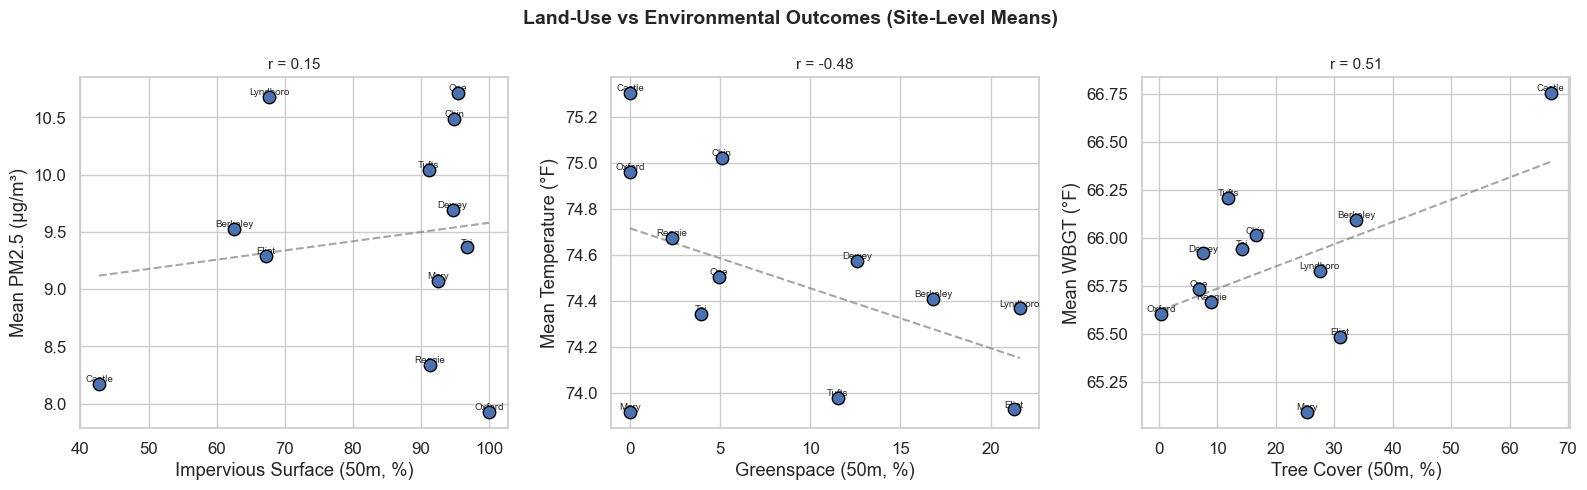

In [ ]:
# Land-use vs environmental outcomes scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Land-Use vs Environmental Outcomes (Site-Level Means)", fontsize=14, fontweight="bold")

site_means = df.groupby("site_id").agg(
    pm25=("pa_mean_pm2_5_atm_b_corr_2", "mean"),
    temp=("kes_mean_temp_f", "mean"),
    wbgt=("kes_mean_wbgt_f", "mean"),
    imperv=("Impervious_Area_Percent_50m", "first"),
    green=("Greenspace_Area_Percent_50m", "first"),
    trees=("Trees_Area_Percent_50m", "first"),
).reset_index()

for ax, (x, y, xl, yl) in zip(axes, [
    ("imperv", "pm25", "Impervious Surface (50m, %)", "Mean PM2.5 (µg/m³)"),
    ("green", "temp", "Greenspace (50m, %)", "Mean Temperature (°F)"),
    ("trees", "wbgt", "Tree Cover (50m, %)", "Mean WBGT (°F)"),
]):
    ax.scatter(site_means[x] * 100, site_means[y], s=80, color=PM_COLOR, edgecolors="black", zorder=5)
    for _, row in site_means.iterrows():
        ax.annotate(SITE_NAMES[row["site_id"]].split()[0], (row[x] * 100, row[y]),
                     fontsize=7, ha="center", va="bottom")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    # Simple trend line
    mask = ~(np.isnan(site_means[x]) | np.isnan(site_means[y]))
    if mask.sum() > 2:
        z = np.polyfit(site_means[x][mask] * 100, site_means[y][mask], 1)
        p = np.poly1d(z)
        xr = np.linspace(site_means[x].min() * 100, site_means[x].max() * 100, 50)
        ax.plot(xr, p(xr), "--", color="gray", alpha=0.7)
        r = np.corrcoef(site_means[x][mask] * 100, site_means[y][mask])[0, 1]
        ax.set_title(f"r = {r:.2f}", fontsize=11)

plt.tight_layout()
plt.show()

## 2.6 — Site Geolocation

Coordinates enriched for all 12 sites. Map shows PM2.5-colored markers sized by mean concentration.

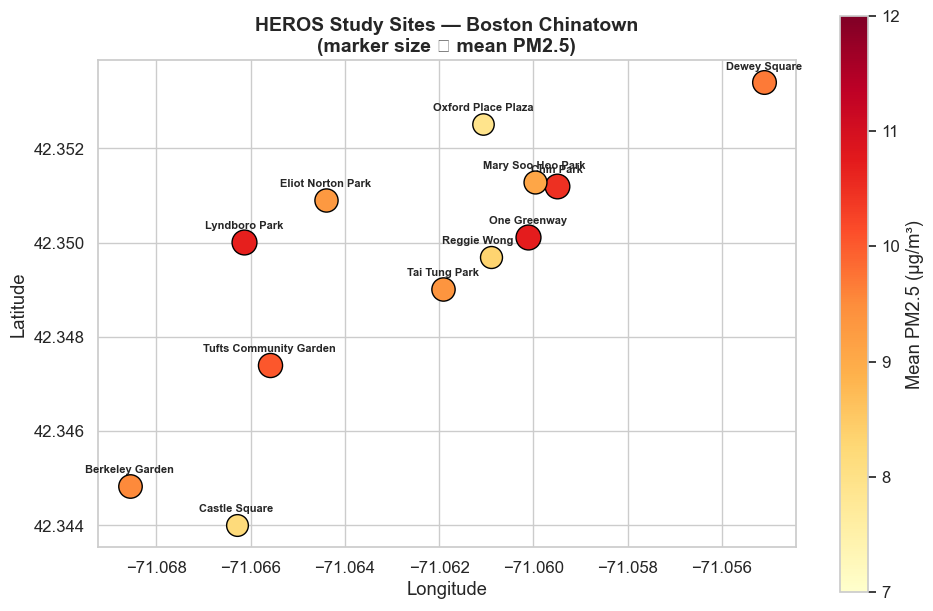

In [ ]:
SITE_COORDS = {
    "berkley": (42.34483, -71.06857), "castle": (42.3440, -71.0663),
    "chin": (42.3512, -71.0595), "dewey": (42.3534, -71.0551),
    "eliotnorton": (42.3509, -71.0644), "greenway": (42.35012, -71.06012),
    "lyndenboro": (42.35001, -71.06614), "msh": (42.35129, -71.05997),
    "oxford": (42.35252, -71.06107), "reggie": (42.3497, -71.0609),
    "taitung": (42.34901, -71.06192), "tufts": (42.3474, -71.0656),
}

fig, ax = plt.subplots(figsize=(10, 10))
for site, (lat, lon) in SITE_COORDS.items():
    pm25 = df[df["site_id"] == site]["pa_mean_pm2_5_atm_b_corr_2"].mean()
    size = max(60, pm25 * 30)
    ax.scatter(lon, lat, s=size, c=pm25, cmap="YlOrRd", vmin=7, vmax=12,
               edgecolors="black", linewidth=1, zorder=5)
    ax.annotate(SITE_NAMES[site], (lon, lat), fontsize=8, fontweight="bold",
                ha="center", va="bottom", xytext=(0, 8), textcoords="offset points")

sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=7, vmax=12))
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.6, label="Mean PM2.5 (µg/m³)")

ax.set_title("HEROS Study Sites — Boston Chinatown\n(marker size ∝ mean PM2.5)", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

report["geolocation"] = {site: {"lat": c[0], "lon": c[1]} for site, c in SITE_COORDS.items()}

In [ ]:
# Save Phase 2 report JSON
report["figures"] = [
    "eda_univariate_histograms.png", "eda_timeseries_pm25.png",
    "eda_timeseries_temp.png", "eda_timeseries_wbgt.png",
    "eda_diurnal_cycles.png", "eda_day_of_week.png",
    "eda_spatial_boxplots.png", "eda_spatial_violins.png",
    "eda_correlation_matrix.png", "eda_landuse_bars.png",
    "eda_landuse_vs_env.png", "eda_site_locations_map.png",
    "eda_hour_dow_heatmap.png",
]

REPORT_DIR = Path(".")
with open(REPORT_DIR / "phase2_report.json", "w") as f:
    json.dump(report, f, indent=2)
print("✓ Saved phase2_report.json")
print(f"\n✅ Phase 2 EDA complete — {len(report['figures'])} figure types generated")

✓ Saved phase2_report.json

✅ Phase 2 EDA complete — 13 figure types generated


## Phase 2 Assessment

| Step | Description | Status |
|------|-------------|--------|
| 2.1 | Univariate analysis | ✅ Histograms + summary stats for 6 variables |
| 2.2 | Temporal patterns | ✅ Time series, diurnal cycles, day-of-week, hour×DOW |
| 2.3 | Spatial overview | ✅ Boxplots + violins across 12 sites |
| 2.4 | Correlation matrix | ✅ 14×14 pairwise correlation heatmap |
| 2.5 | Land-use summary | ✅ Stacked bars + scatter vs environment |
| 2.6 | Geolocation | ✅ Coordinates added, site map generated |

### Key Hypotheses for Phase 3
1. PM2.5 sensor correction equations (Q1) should yield strong fits given r > 0.93
2. ~3 µg/m³ intra-neighborhood gradient may be explained by land-use (Q9)
3. WBGT peaks later than temperature — separate metrics tell different stories (Q5)
4. No weekday/weekend PM2.5 effect — regional transport may dominate (Q8)
5. One Greenway paradox: highest PM2.5 + most greenspace → roadway proximity? (Q9)

**Phase 2 is complete. Ready for Phase 3: Research Questions (Q1–Q9).**